In [1]:
import h5py, os, pzflow
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pzflow import Flow
from pzflow.bijectors import Chain, ShiftBounds, RollingSplineCoupling, StandardScaler
from pzflow.distributions import Uniform, Normal, CentBeta, CentBeta13

from emcee import EnsembleSampler
from trianglechain import TriangleChain

from msfm.utils import prior, parameters

23-06-26 16:57:21    scales.py INF   Setting up healpy to run on 10 CPUs 


/Users/arne/miniforge3/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_test_split = 0.8

# network predictions

In [3]:
def load_preds(base_dir, model_dir, n_steps=None, file_label=None):
    out_dir = os.path.join(base_dir, model_dir)
    
    if n_steps is None:
        preds_file = os.path.join(out_dir, f"preds.h5")
    elif file_label is None:
        preds_file = os.path.join(out_dir, f"preds_{n_steps}.h5")
    else:
        preds_file = os.path.join(out_dir, f"preds_{n_steps}_{file_label}.h5")

    with h5py.File(preds_file, "r") as f:
        # fiducial
        fidu_train_preds = f["fiducial/train/pred"][:]
        fidu_vali_preds = f["fiducial/vali/pred"][:]

        print(f"fidu_train_preds =   {fidu_train_preds.shape}")
        print(f"fidu_vali_preds =    {fidu_vali_preds.shape}")

        # grid
        grid_preds = f["grid/pred"][:]
        grid_cosmos = f["grid/cosmo"][:]
        grid_sobol = f["grid/i_sobol"][:]
        print(f"grid_preds.shape =   {grid_preds.shape}")
        print(f"grid_cosmos.shape =  {grid_cosmos.shape}")
        print(f"grid_sobol.shape =   {grid_cosmos.shape}")

    return fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol

### choose a run

In [4]:
base_dir = "/Users/arne/data/DESY3/models/v3/"

In [5]:
# # clustering only
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

In [6]:
# # clustering only, with and without survey systematics
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

# # without survey systematics
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}_no_survey_systematics.h5")

# with h5py.File(preds_file, "r") as f:
#     # fiducial
#     no_survey_systematics_fidu_vali_preds = f["fiducial/vali/pred"][:]
    
# print(no_survey_systematics_fidu_vali_preds.shape)


In [7]:
# lensing only
model_dir = "2023-05-29_09-55-49_resnet_vanilla"
n_steps = 50000

param_labels = ["Om", "s8", "Aia", "n_Aia"]
param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$']
fiducial_point = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5}

fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

fidu_train_preds =   (750, 4)
fidu_vali_preds =    (50, 4)
grid_preds.shape =   (2499, 16, 4)
grid_cosmos.shape =  (2499, 4)
grid_sobol.shape =   (2499, 4)


In [8]:
# # combined probes
# model_dir = "2023-05-30_10-56-53_resnet_vanilla"
# n_steps = 10000

# param_labels = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

### construct the dataframe

In [9]:
n_params = len(param_labels)
n_examples = grid_preds.shape[1]
assert fidu_train_preds.shape[1] == fidu_vali_preds.shape[1] == grid_preds.shape[2]
n_summaries = grid_preds.shape[2]
summary_labels = [f"summary_{i}" for i in range(n_summaries)]

In [10]:
obs_pred = np.median(fidu_vali_preds, axis=0)

# obs_pred = fidu_vali_preds[0]
# obs_pred = no_survey_systematics_fidu_vali_preds[0]

obs_df = pd.DataFrame([obs_pred], columns=[f"summary_{i}" for i in range(n_summaries)])

In [11]:
df_list = []
for i in range(n_examples):

    df_sobol = pd.DataFrame(grid_sobol, columns=["sobol"])

    df_cosmo = pd.DataFrame()
    for j, cosmo_param in enumerate(param_labels):
        df_cosmo[cosmo_param] = grid_cosmos[:,j]

    df_summary = pd.DataFrame()
    for j in range(n_summaries):
        df_summary[f"summary_{j}"] = grid_preds[:,i,j]

    df_list.append(df_sobol.join([df_cosmo, df_summary]))

# combine along the example axis
df_total = pd.concat(df_list, axis=0)
df_total = df_total.sample(frac=1.0)

# train/test split
df_train = df_total[: int(train_test_split * len(df_total))]
df_val = df_total[int(train_test_split* len(df_total)) :]


# normalizing flow

In [12]:
# fig, ax = plt.subplots(ncols=2)

# latent_1d = Normal(input_dim=1)
# samples = latent_1d.sample(params=None, nsamples=100000)
# samples = jnp.squeeze(samples)
# ax[0].hist(samples, bins=100, label="normal")

# latent_1d = CentBeta13(input_dim=1)
# samples = latent_1d.sample(params=None, nsamples=100000)
# samples = jnp.squeeze(samples)
# ax[1].hist(samples, bins=100, label="beta 13");

Training 100 epochs 
Loss:
(0) 10.6890
(1) 2.2665
(6) -0.9390
(11) -1.8750
(16) -2.1346
(21) -2.4651
(26) -2.5787
(31) -2.6667
(36) -2.7640
(41) -2.8667
(46) -2.9128
(51) -2.9782
(56) -3.0005
(61) -3.0585
(66) -3.1023
(71) -3.1345
(76) -3.1451
(81) -3.2373
(86) -3.1842
(91) -3.2818
(96) -3.2523
(100) -3.3063


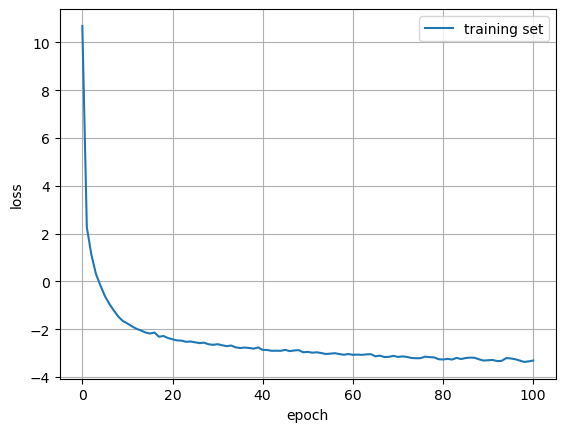

In [17]:
latent = CentBeta13(input_dim=n_summaries, B=5)
# bijector = Chain(
#     ShiftBounds(jnp.array(df_total[summary_labels].min(axis=0)), jnp.array(df_total[summary_labels].max(axis=0)), B=4),
#     RollingSplineCoupling(n_summaries, B=5, n_conditions=n_params, hidden_dim=128),
# )

flow = Flow(
    data_columns=param_labels, 
    conditional_columns=summary_labels, 
    latent=latent,
    # bijector=bijector,
)

# train
# loss_train, loss_val = flow.train(df_train, df_val, verbose=True, epochs=100)
loss_train = flow.train(df_total, verbose=True, epochs=100, batch_size=4096)

# plot
fig, ax = plt.subplots()
ax.plot(loss_train, label="training set")
# ax.plot(loss_val, label="validation set")
ax.set(xlabel="epoch", ylabel="loss")
ax.legend()
ax.grid(True)

# MCMC

In [18]:
def log_posterior(X): 
    # convert to dataframe
    X = pd.DataFrame(X, columns=param_labels)
    X = X.join(obs_df, how="cross")

    # evaluate the normalizing flow
    log_prob = flow.log_prob(X)
    
    # enforce the prior
    log_prob = prior.log_posterior(X.loc[:,param_labels], log_prob, params=param_labels, conf=None)

    return log_prob

In [19]:
# emcee setup
np.random.seed(42)

nwalkers = 1024
p0 = np.random.normal(loc=parameters.get_fiducials(param_labels), scale=1e-3, size=(nwalkers, n_params))
print("Initial values in prior: ", np.all(prior.in_grid_prior(p0, params=param_labels))) 

Initial values in prior:  True


In [20]:
# sample burn in
sampler = EnsembleSampler(nwalkers, n_params, log_posterior, vectorize=True)
state = sampler.run_mcmc(p0, 100)
sampler.reset()

# run the actual chain
sampler.run_mcmc(state, 1000, progress=True)

# save the result
chain = sampler.get_chain(flat=True)
np.save(os.path.join(base_dir, model_dir, f"chain_{n_steps}_flow_posterior.npy"), chain)

100%|██████████| 1000/1000 [01:30<00:00, 11.10it/s]


# plot

### compare GP ABC to normalizing flow

100%|██████████| 6/6 [00:00<00:00, 1340.25it/s]


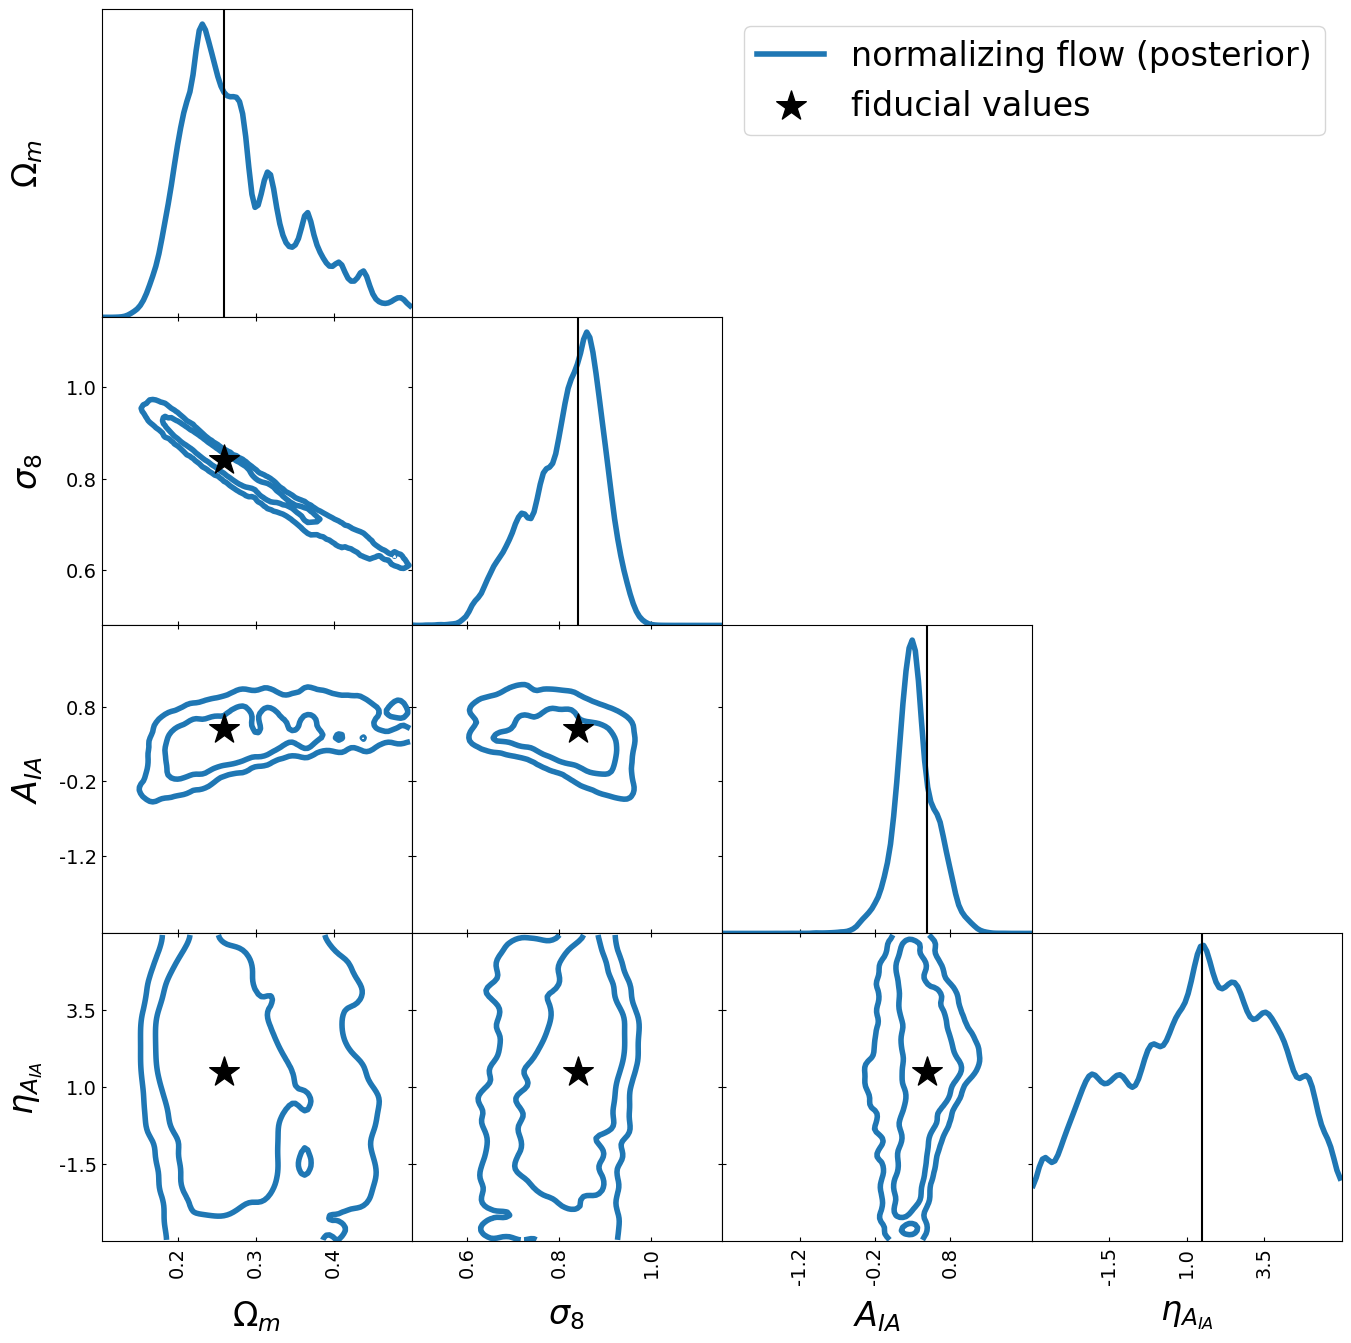

In [21]:
tri = TriangleChain(labels=param_latex, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})

# GP ABC
# gp_abc_chain = np.load(os.path.join(base_dir, model_dir, f"chain_{n_steps}.npy"))
# tri.contour_cl(gp_abc_chain, names=param_latex, label="GP ABC")

# normalizing flow
tri.contour_cl(chain, names=param_labels, label="normalizing flow (posterior)")

# fiducial
tri.scatter(
    fiducial_point,
    label="fiducial values",
    plot_histograms_1D=False,
    color="k",
    show_legend=True,
    scatter_vline_1D=True,
)
tri.fig.savefig(os.path.join(base_dir, model_dir, f"contours_{n_steps}_flow_posterior.png"), bbox_inches="tight", dpi=300)

### compare with and without survey systematics correction

In [ ]:
# tri = TriangleChain(labels=param_labels, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})

# # with systematics
# chain = np.load(os.path.join(base_dir, model_dir, f"chain_{n_steps}_flow_survey_systematics.npy"))
# tri.contour_cl(chain, names=param_labels, label="flow, with survey systematics")

# # without systematics
# chain = np.load(os.path.join(base_dir, model_dir, f"chain_{n_steps}_flow_no_survey_systematics.npy"))
# tri.contour_cl(chain, names=param_labels, label="flow, without survey systematics")

# # fiducial
# tri.scatter(
#     fiducial_point,
#     label="fiducial values",
#     plot_histograms_1D=False,
#     color="k",
#     show_legend=True,
#     scatter_vline_1D=True,
# )
# tri.fig.savefig(os.path.join(base_dir, model_dir, f"contours_{n_steps}_flow_systematics.png"), bbox_inches="tight", dpi=300)